In [56]:
from itertools import count

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import subplots_adjust

#root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
#sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "09_ex_con_2025_full_logit_mean_one"

#scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_total = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0', 'root_area_index', 'wcont_sigma_deviation','g_stem_res']

vars_plant = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1','jackson_root_beta', 'g_stem_res']

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.2]
index_to_drop = df[(df['sid'] == 2) | (df['sid'] == 2)].index
df.drop(index_to_drop, inplace=True)
df_mean = df.groupby(['id'])[vars_total].mean()
df_mean.shape

(17954, 16)

In [57]:
df

,Unnamed: 0,index,id,root_area_index,canopy_height,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
42560,0,8744,8512,12.107985,35,1800.0,1800,False,1.0,1.75,...,0.523006,0.176193,0.517530,0.442549,0.598874,0.528981,0.465454,0.884543,0.969696,0
42561,1,1212,8512,9.660008,35,1800.0,1800,False,1.0,1.75,...,7.312399,7.482171,4.108914,4.332433,4.086924,4.001949,4.620663,0.884543,0.969696,1
42564,4,366,8512,9.372908,35,1800.0,1800,False,1.0,1.75,...,6.418607,6.584066,4.155360,4.418611,4.131725,4.110512,4.556913,0.884543,0.969696,4
42563,3,6694,8512,9.108738,35,1800.0,1800,False,1.0,1.75,...,6.439473,6.605046,3.852520,4.086848,3.825552,3.804541,4.293714,0.884543,0.969696,3
135003,3,6276,27000,9.304597,35,1800.0,1800,False,1.0,1.75,...,6.338611,6.503623,3.779201,4.011116,3.755323,3.733092,4.216254,0.784827,0.971815,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106125,0,1824,21225,6.027287,35,1800.0,1800,False,1.0,1.75,...,0.766041,0.113850,0.688743,0.619347,0.712368,0.643351,0.575998,0.897501,1.199996,0
17383,3,6960,3476,6.823803,35,1800.0,1800,False,1.0,1.75,...,7.829903,8.001713,4.460126,4.704287,4.429555,4.348063,4.997807,1.117040,1.200000,3
17381,1,6960,3476,6.823803,35,1800.0,1800,False,1.0,1.75,...,7.829903,8.001713,4.460126,4.704287,4.429555,4.348063,4.997807,1.117040,1.200000,1
17384,4,7214,3476,8.233650,35,1800.0,1800,False,1.0,1.75,...,7.602031,7.772978,4.649075,4.925707,4.616379,4.600849,5.149403,1.117040,1.200000,4


In [58]:
df_norm = (df_mean - df_mean.mean()) / df_mean.std()

In [59]:
df_norm[vars_plant]

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,jackson_root_beta,g_stem_res
id,,,,,,,,,,,
2,-0.117504,0.335378,-1.514309,0.231229,0.143596,-1.419021,-0.025249,-1.252362,0.894539,-0.706309,-0.015061
4,0.203319,-0.165887,0.483924,0.103986,-0.512392,-0.819193,-0.665557,-0.409614,-1.410252,0.316149,-0.679188
7,-0.961821,1.420235,-1.061660,1.078565,-0.093143,1.263623,-0.645498,-0.004280,1.618851,0.250415,0.218013
8,-1.896320,1.562082,1.067701,-0.437091,0.041313,1.426875,1.487197,2.335099,0.367469,-0.524968,-0.582954
9,-0.261648,-0.042591,1.142429,0.706168,-0.137362,1.704643,0.024197,1.775966,-0.487503,-1.269582,2.805080
...,...,...,...,...,...,...,...,...,...,...,...
44438,0.129998,-1.037726,2.043704,1.211005,-1.319886,0.721920,-0.928921,1.574977,0.342848,-0.245100,2.085930
44439,0.537008,1.521383,-1.270862,0.319855,1.044035,-0.135775,-0.161062,0.832683,0.746471,0.169102,0.877529
44440,0.701150,0.106907,-1.625224,0.342754,0.805869,0.765986,-0.269636,-1.036735,0.413784,0.077159,-1.303072


In [60]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [61]:
vars_sel = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value','g0', 'g_stem_res','psi_leaf_50_close', 'd_50_close']
label_dict  = {}
label_dict['huber_value'] = r"Huber $\mathcal{H}$"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{close}$"
label_dict['d_50_close'] = r"$d_{close}$"
label_dict['g_stem_res'] = r"$g_\mathrm{Stem}$"


unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "-"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g_stem_res'] = "mol m-1 s-1"
unit_dict['psi_leaf_50_close'] = r"MPa"
unit_dict['d_50_close'] = "-"



In [49]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,root_area_index,wcont_sigma_deviation,g_stem_res
id,,,,,,,,,,,,,,,,
0,1.318949,-0.736029,1.179522,-1.581590,0.207914,-1.100962,-1.070582,-0.532159,1.260582,0.047018,-1.135339,-1.758485,-1.255712,0.864581,-1.648875,0.305379
2,-0.633843,0.413328,-1.438705,0.277655,-0.006026,-1.461601,0.624182,-1.270117,0.799889,-0.341698,0.533017,-1.226662,1.287693,1.292844,0.994920,-0.004207
4,-0.193160,-0.216433,0.665328,0.021927,-0.462159,-0.746059,0.376871,-0.527274,-1.349946,0.004217,-0.376923,-0.038872,-1.692533,-1.583802,-0.100415,-0.764958
7,-1.085977,1.187818,-0.986397,0.984595,-0.190446,1.462481,-0.913551,-0.048996,1.572003,0.855767,-0.076700,0.434952,0.103815,0.780177,1.771156,0.253557
8,-1.860024,1.653990,1.022644,-0.385585,-0.011802,1.706581,1.322660,2.213652,0.508015,0.570255,1.124570,-0.345030,0.850808,0.285461,0.161462,-0.663415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44439,-0.234980,1.308022,-1.195063,0.277212,1.036864,-0.197825,0.509903,0.849347,0.765582,-0.383776,-0.222732,0.403391,1.915279,1.544400,-0.339881,0.793150
44440,0.165750,-0.013396,-1.502507,0.307899,0.799580,0.787274,0.040403,-1.048090,0.389470,-1.300117,0.270510,-0.016292,-0.457411,-0.406809,-0.131016,-1.327548
44441,1.986882,-0.208637,-0.899947,-1.094713,1.557553,-1.299561,0.078253,0.416851,1.200602,-0.486429,-0.029257,1.071545,-0.168633,-0.091540,-0.431495,1.620235


In [62]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(df_norm[vars_plant])

KMeans(n_clusters=3, random_state=0)

In [63]:
K = range(2, 12)
fits = []

scorss = []
for s in range(10):
    score = []
    for k in K:
        # train the model for current value of k on training data
        model = KMeans(n_clusters = k, random_state = s, n_init='auto').fit(df_norm[vars_sel])

        # append the model to fits
        fits.append(model)

        # Append the silhouette score to scores
        score.append(silhouette_score(df_norm[vars_sel], model.labels_, metric='euclidean'))
    scorss.append(score)
    print(s)


0
1
2
3
4
5
6
7
8
9


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

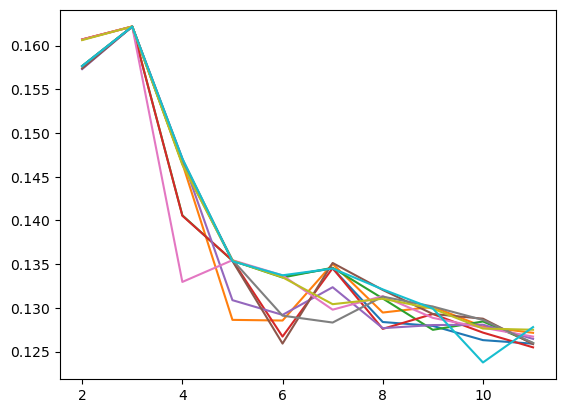

In [64]:
plt.plot(K, np.array(scorss).T);

In [36]:
kmeans = KMeans(n_clusters = 3, random_state = 9
                , n_init='auto')
kmeans.fit(df_norm[vars_sel])
np.round(silhouette_score(df_norm[vars_sel], kmeans.labels_, metric='euclidean'),3)


np.float64(0.172)

In [38]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)
counts
countslabs = [f'G{i+1} ({counts[i]})'for i in range(3)]


In [39]:
vars_sel

['stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'g0',
 'g_stem_res',
 'psi_leaf_50_close',
 'd_50_close']

/tmp/ipykernel_502497/1047333090.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_502497/1047333090.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_502497/1047333090.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_502497/1047333090.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_502497/1047333090.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)


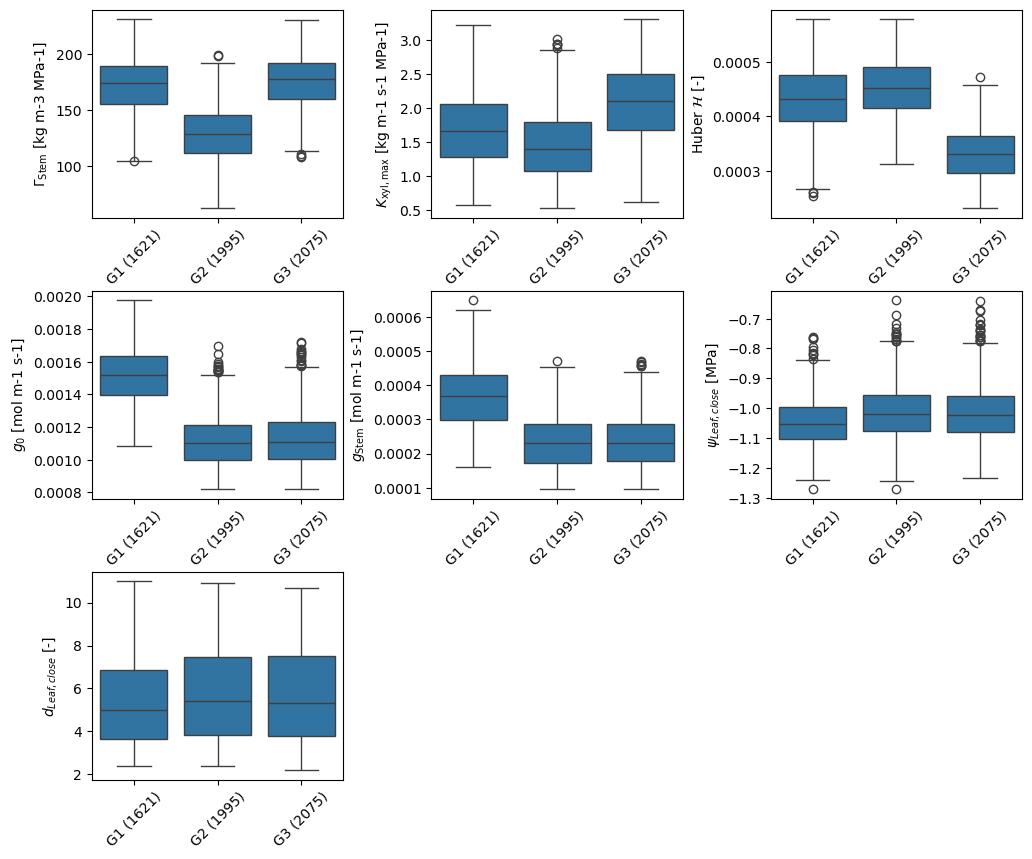

In [40]:
MOL_TO_KG = 18.0/1000.0
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, 8+1), vars_sel):
    ax = fig.add_subplot(3,3, index)
    ax.set_xticklabels(countslabs)
    ax.set_ylabel(f"{label_dict[vars_sel[index-1]]} [{unit_dict[vars_sel[index-1]]}]")
    
    if  var == 'stem_hydraulic_capacitance':
        sns.boxplot(x = kmeans.labels_, y = df_mean[var] * MOL_TO_KG, ax=ax)
    elif var == 'k_xylem_sat':
        sns.boxplot(x = kmeans.labels_, y = df_mean[var] * MOL_TO_KG, ax=ax)
    else:
        sns.boxplot(x = kmeans.labels_, y = df_mean[var], ax=ax)
    ax.tick_params(axis='x', labelrotation=45)

plt.subplots_adjust(wspace=0.35, hspace=0.35)
plt.savefig(f"{post_path}/figure4_kmeans_cluster.png", bbox_inches='tight', dpi = 300)

In [16]:
from sklearn.cluster import MeanShift
from sklearn import metrics

db = MeanShift(bandwidth=2).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

Estimated number of clusters: 5
Estimated number of noise points: 0
Silhouette Coefficient: 0.041


In [16]:
df_norm[vars_plant]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,jackson_root_beta
id,,,,,,,,
0,-0.601464,1.145214,0.593686,1.227873,-2.142011,-2.047083,-0.991387,-0.736660
1,-0.505121,-0.872027,-0.098686,-0.794584,1.755737,1.980279,-1.392011,0.734571
2,1.412511,0.534290,0.514407,-0.280269,1.284822,1.306727,1.622993,2.429507
3,0.598750,-0.964184,0.907454,-0.669782,0.260972,1.040270,0.425506,0.440895
4,-0.263877,0.727996,0.548335,1.939314,0.978791,0.045805,0.180179,-0.495927
...,...,...,...,...,...,...,...,...
23694,-0.113747,0.276975,1.328484,1.707235,-0.075766,0.262491,2.640747,-1.652910
23695,-0.601057,-0.126646,-0.997181,-0.805152,1.175334,0.476110,-0.954902,0.152204
23696,0.553392,0.628877,0.964663,0.057998,0.602677,1.493658,0.034281,0.840595


In [ ]:
unique, counts = numpy.unique(a, return_counts=True)

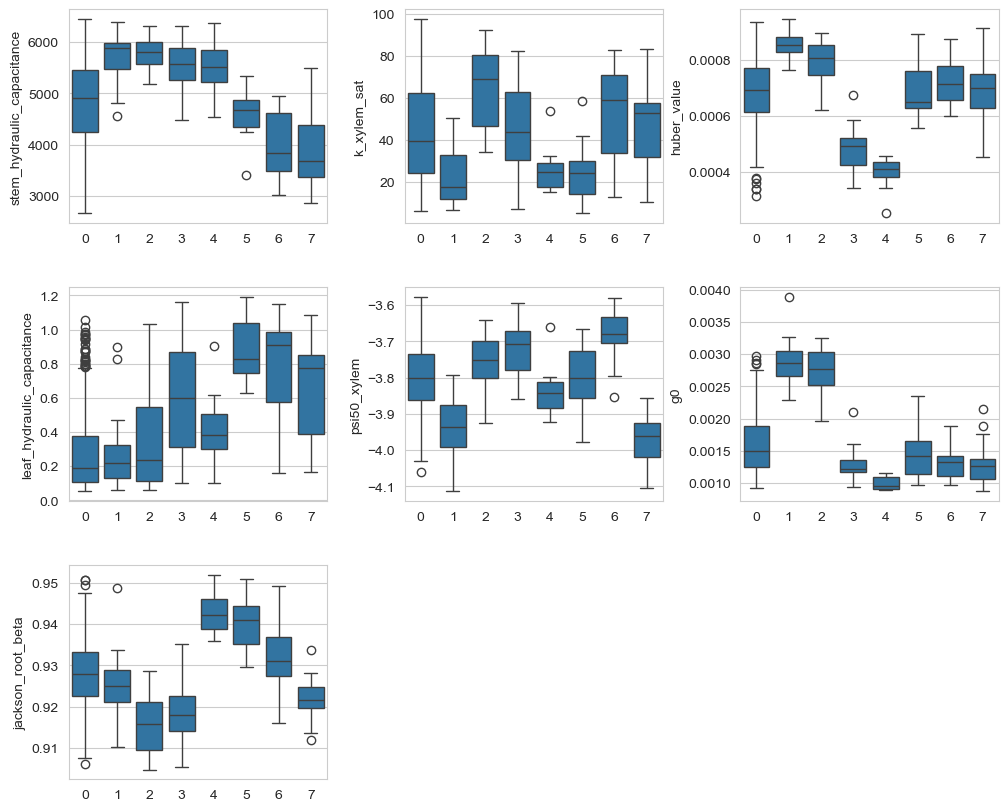

In [40]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_plant)+1), vars_plant):
    ax = fig.add_subplot(3,3, index)
    sns.boxplot(x = labels, y = df_mean[var], ax=ax)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

<Axes: >

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

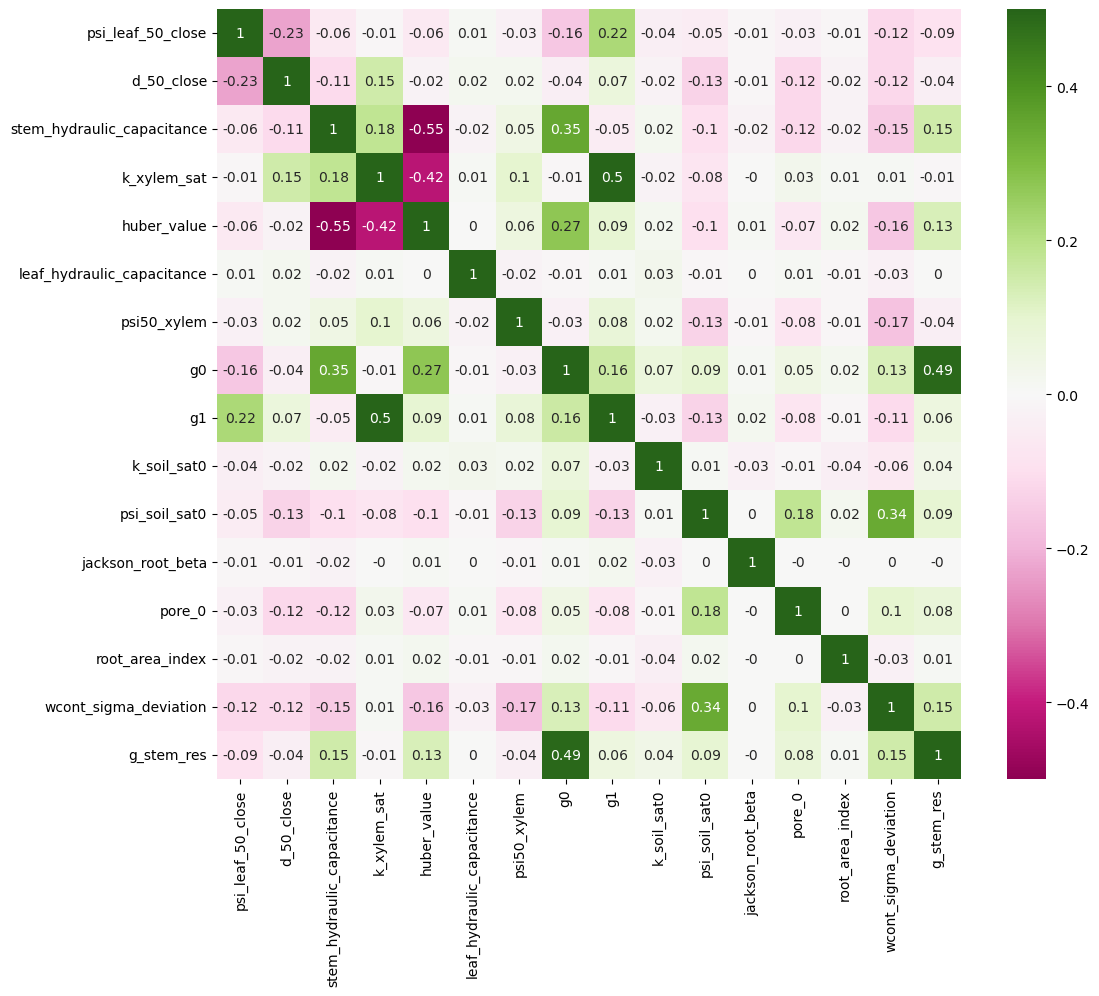

In [30]:
corr_matrix = df_mean.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")